In [1]:
# Cell 1: Imports
import os
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, regularizers, callbacks
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, clear_output

# Verify GPU
print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU available: {gpus[0].name}")
    tf.config.experimental.set_memory_growth(gpus[0], True)
else:
    print("No GPU found — running on CPU (will be slow)")

print("All imports done.")

TensorFlow version: 2.20.0
GPU available: /physical_device:GPU:0
All imports done.


In [2]:
# Cell 2A: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("Drive mounted successfully.")

Mounted at /content/drive
Drive mounted successfully.


In [3]:
# Cell 2B: Paths and Hyperparameters

# ── Paths ──────────────────────────────────────────────────────────────
BASE  = '/content/drive/MyDrive/LungTumour/'
LOCAL = '/content/lung_data/'

BASELINE_WEIGHTS_H5    = BASE + 'attention_unet_best.h5'       # original saved weights
BASELINE_WEIGHTS_KERAS = BASE + 'attention_unet_best.keras'    # clean re-save (done in Cell 4)
FINETUNED_WEIGHTS      = BASE + 'M4_finetuned_best.keras'      # fine-tuned model save path

# ── Data files ─────────────────────────────────────────────────────────
X_TRAIN = LOCAL + 'X_train.npy'
Y_TRAIN = LOCAL + 'y_train.npy'
X_VAL   = LOCAL + 'X_val.npy'
Y_VAL   = LOCAL + 'y_val.npy'
X_TEST  = LOCAL + 'X_test.npy'
Y_TEST  = LOCAL + 'y_test.npy'

# ── Hyperparameters ────────────────────────────────────────────────────
INPUT_SHAPE      = (8, 128, 128, 1)
FT_BATCH_SIZE    = 2
EPOCHS           = 30
STEPS_PER_EPOCH  = 1840 // FT_BATCH_SIZE    # = 920
VAL_STEPS        = 200  // FT_BATCH_SIZE     # = 100
LR_START         = 1e-4
LR_END           = 1e-6
EARLY_STOP_PAT   = 10

# ── Baseline reference (for final comparison table) ────────────────────
BASELINE = {
    'val_dice'   : 0.7429,
    'test_dice'  : 0.7234,
    'test_dice_std': 0.2219,
    'test_iou'   : 0.6031,
    'precision'  : 0.8229,
    'sensitivity': 0.7168,
    'specificity'  : 0.9994
}

print("Paths:")
print(f"  Baseline H5     : {BASELINE_WEIGHTS_H5}")
print(f"  Baseline Keras  : {BASELINE_WEIGHTS_KERAS}")
print(f"  Fine-tuned save : {FINETUNED_WEIGHTS}")
print(f"\nHyperparameters:")
print(f"  Batch size      : {FT_BATCH_SIZE}")
print(f"  Epochs          : {EPOCHS}")
print(f"  Steps/epoch     : {STEPS_PER_EPOCH}")
print(f"  LR start → end  : {LR_START} → {LR_END}")
print(f"  Early stop pat  : {EARLY_STOP_PAT}")

Paths:
  Baseline H5     : /content/drive/MyDrive/LungTumour/attention_unet_best.h5
  Baseline Keras  : /content/drive/MyDrive/LungTumour/attention_unet_best.keras
  Fine-tuned save : /content/drive/MyDrive/LungTumour/M4_finetuned_best.keras

Hyperparameters:
  Batch size      : 2
  Epochs          : 30
  Steps/epoch     : 920
  LR start → end  : 0.0001 → 1e-06
  Early stop pat  : 10


In [4]:
# Cell 3: Loss Functions and Metrics

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def bce_dice_loss(y_true, y_pred):
    bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))
    dice = 1 - dice_coefficient(y_true, y_pred)
    return 0.5 * bce + 0.5 * dice

def compute_metrics(y_true, y_pred_bin):
    results = []
    for i in range(len(y_true)):
        gt   = y_true[i].flatten()
        pred = y_pred_bin[i].flatten()
        TP = np.sum(gt * pred)
        FP = np.sum((1 - gt) * pred)
        FN = np.sum(gt * (1 - pred))
        TN = np.sum((1 - gt) * (1 - pred))
        results.append({
            'dice'       : (2*TP + 1e-6) / (2*TP + FP + FN + 1e-6),
            'iou'        : (TP + 1e-6)   / (TP + FP + FN + 1e-6),
            'sensitivity': (TP + 1e-6)   / (TP + FN + 1e-6),
            'precision'  : (TP + 1e-6)   / (TP + FP + 1e-6),
            'specificity': (TN + 1e-6)   / (TN + FP + 1e-6)
        })
    return results

# Needed when loading the old .h5 file in Cell 4
CUSTOM_OBJECTS = {
    'bce_dice_loss'    : bce_dice_loss,
    'dice_coefficient' : dice_coefficient
}

print("Loss functions defined:")
print("  ✓ dice_coefficient  (smooth=1e-6)")
print("  ✓ bce_dice_loss     (0.5*BCE + 0.5*Dice)")
print("  ✓ compute_metrics   (Dice, IoU, Sensitivity, Precision, Specificity)")
print("  ✓ CUSTOM_OBJECTS    (ready for .h5 loading)")

Loss functions defined:
  ✓ dice_coefficient  (smooth=1e-6)
  ✓ bce_dice_loss     (0.5*BCE + 0.5*Dice)
  ✓ compute_metrics   (Dice, IoU, Sensitivity, Precision, Specificity)
  ✓ CUSTOM_OBJECTS    (ready for .h5 loading)


In [5]:
# Cell 4: Rebuild Architecture + Load Baseline Weights + Re-save as .keras

# ── Architecture ───────────────────────────────────────────────────────
L2 = 1e-4

def conv_block(x, filters, dropout_rate=0.2):
    for _ in range(2):
        x = layers.Conv3D(filters, (3,3,3), padding='same',
                          kernel_regularizer=regularizers.l2(L2))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
    x = layers.SpatialDropout3D(dropout_rate)(x)
    return x

def attention_gate(x, g, filters):
    theta_x = layers.Conv3D(filters, (1,1,1), padding='same',
                            kernel_regularizer=regularizers.l2(L2))(x)
    phi_g   = layers.Conv3D(filters, (1,1,1), padding='same',
                            kernel_regularizer=regularizers.l2(L2))(g)
    phi_g   = layers.UpSampling3D(size=(1,2,2))(phi_g)
    add     = layers.Add()([theta_x, phi_g])
    act     = layers.Activation('relu')(add)
    psi     = layers.Conv3D(1, (1,1,1), padding='same')(act)
    sigmoid = layers.Activation('sigmoid')(psi)
    return layers.Multiply()([x, sigmoid])

def build_attention_unet(input_shape=(8, 128, 128, 1)):
    inputs = layers.Input(input_shape)
    c1 = conv_block(inputs, 16,  dropout_rate=0.1)
    p1 = layers.MaxPooling3D((1, 2, 2))(c1)
    c2 = conv_block(p1,     32,  dropout_rate=0.1)
    p2 = layers.MaxPooling3D((1, 2, 2))(c2)
    c3 = conv_block(p2,     64,  dropout_rate=0.2)
    p3 = layers.MaxPooling3D((1, 2, 2))(c3)
    c4 = conv_block(p3,     128, dropout_rate=0.3)
    u1 = layers.UpSampling3D((1, 2, 2))(c4)
    a1 = attention_gate(c3, c4, 64)
    u1 = layers.Concatenate()([u1, a1])
    c5 = conv_block(u1,     64,  dropout_rate=0.2)
    u2 = layers.UpSampling3D((1, 2, 2))(c5)
    a2 = attention_gate(c2, c5, 32)
    u2 = layers.Concatenate()([u2, a2])
    c6 = conv_block(u2,     32,  dropout_rate=0.1)
    u3 = layers.UpSampling3D((1, 2, 2))(c6)
    a3 = attention_gate(c1, c6, 16)
    u3 = layers.Concatenate()([u3, a3])
    c7 = conv_block(u3,     16,  dropout_rate=0.1)
    outputs = layers.Conv3D(1, (1,1,1), activation='sigmoid',
                            kernel_regularizer=regularizers.l2(L2))(c7)
    return tf.keras.Model(inputs, outputs, name='Attention_UNet_3D')

# ── Build fresh model ──────────────────────────────────────────────────
model = build_attention_unet(INPUT_SHAPE)
print(f"Model built  — Total params: {model.count_params():,}")

# ── Load baseline .h5 weights ──────────────────────────────────────────
print(f"\nLoading baseline weights from:\n  {BASELINE_WEIGHTS_H5}")
baseline_model = tf.keras.models.load_model(
    BASELINE_WEIGHTS_H5,
    custom_objects=CUSTOM_OBJECTS
)
model.set_weights(baseline_model.get_weights())
print("Baseline weights loaded into fresh model ✓")

# Free memory — we don't need the old model object anymore
del baseline_model

# ── Re-save as .keras (clean format, no warnings ever again) ───────────
model.save(BASELINE_WEIGHTS_KERAS)
print(f"\nRe-saved as .keras:\n  {BASELINE_WEIGHTS_KERAS}")
print("\nFrom this point forward — .h5 is never used again.")

Model built  — Total params: 1,478,868

Loading baseline weights from:
  /content/drive/MyDrive/LungTumour/attention_unet_best.h5


Baseline weights loaded into fresh model ✓

Re-saved as .keras:
  /content/drive/MyDrive/LungTumour/attention_unet_best.keras

From this point forward — .h5 is never used again.


In [6]:
# Cell 5A: Copy Data from Drive to Local Storage

import shutil

os.makedirs(LOCAL, exist_ok=True)

files_to_copy = ['X_train.npy', 'y_train.npy',
                 'X_val.npy',   'y_val.npy',
                 'X_test.npy',  'y_test.npy']

print("Copying files from Drive to local storage...")
for fname in files_to_copy:
    src  = BASE + fname
    dst  = LOCAL + fname
    if os.path.exists(dst):
        print(f"  Already exists, skipping : {fname}")
    else:
        print(f"  Copying : {fname} ...", end=' ')
        shutil.copy2(src, dst)
        size_mb = os.path.getsize(dst) / (1024**2)
        print(f"done  ({size_mb:.1f} MB)")

print("\nAll files ready in local storage.")

Copying files from Drive to local storage...
  Copying : X_train.npy ... done  (920.5 MB)
  Copying : y_train.npy ... done  (920.5 MB)
  Copying : X_val.npy ... done  (197.0 MB)
  Copying : y_val.npy ... done  (197.0 MB)
  Copying : X_test.npy ... done  (197.5 MB)
  Copying : y_test.npy ... done  (197.5 MB)

All files ready in local storage.


In [7]:
# Cell 5: Load Data + tf.data Pipeline

# ── Load .npy files ────────────────────────────────────────────────────
print("Loading data...")
X_train = np.load(X_TRAIN)
y_train = np.load(Y_TRAIN)
X_val   = np.load(X_VAL)
y_val   = np.load(Y_VAL)
X_test  = np.load(X_TEST)
y_test  = np.load(Y_TEST)

print(f"  X_train : {X_train.shape}  dtype={X_train.dtype}")
print(f"  y_train : {y_train.shape}  dtype={y_train.dtype}")
print(f"  X_val   : {X_val.shape}    dtype={X_val.dtype}")
print(f"  y_val   : {y_val.shape}    dtype={y_val.dtype}")
print(f"  X_test  : {X_test.shape}   dtype={X_test.dtype}")
print(f"  y_test  : {y_test.shape}   dtype={y_test.dtype}")

# ── Augmentation (exact, unchanged) ───────────────────────────────────
def augment_tf(volume, mask):
    if tf.random.uniform(()) > 0.5:
        volume = tf.reverse(volume, axis=[2])
        mask   = tf.reverse(mask,   axis=[2])
    if tf.random.uniform(()) > 0.5:
        volume = tf.reverse(volume, axis=[1])
        mask   = tf.reverse(mask,   axis=[1])
    if tf.random.uniform(()) > 0.5:
        noise  = tf.random.normal(tf.shape(volume), mean=0.0, stddev=0.02)
        volume = tf.clip_by_value(volume + noise, 0.0, 1.0)
    if tf.random.uniform(()) > 0.5:
        factor = tf.random.uniform((), 0.9, 1.1)
        volume = tf.clip_by_value(volume * factor, 0.0, 1.0)
    return volume, mask

# ── tf.data Pipeline ───────────────────────────────────────────────────
AUTOTUNE = tf.data.AUTOTUNE

# Training pipeline — shuffle → augment → batch → prefetch
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = (train_dataset
                 .shuffle(buffer_size=len(X_train), seed=42)
                 .map(augment_tf, num_parallel_calls=AUTOTUNE)
                 .batch(FT_BATCH_SIZE)
                 .prefetch(AUTOTUNE))

# Validation pipeline — no augmentation, just batch → prefetch
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = (val_dataset
               .batch(FT_BATCH_SIZE)
               .prefetch(AUTOTUNE))

print(f"\ntf.data pipelines ready:")
print(f"  Train batches : {STEPS_PER_EPOCH}  (batch_size={FT_BATCH_SIZE})")
print(f"  Val batches   : {VAL_STEPS}         (batch_size={FT_BATCH_SIZE})")
print(f"  Augmentation  : ON for train, OFF for val")

Loading data...
  X_train : (1841, 8, 128, 128, 1)  dtype=float32
  y_train : (1841, 8, 128, 128, 1)  dtype=float32
  X_val   : (394, 8, 128, 128, 1)    dtype=float32
  y_val   : (394, 8, 128, 128, 1)    dtype=float32
  X_test  : (395, 8, 128, 128, 1)   dtype=float32
  y_test  : (395, 8, 128, 128, 1)   dtype=float32

tf.data pipelines ready:
  Train batches : 920  (batch_size=2)
  Val batches   : 100         (batch_size=2)
  Augmentation  : ON for train, OFF for val


In [9]:
# Cell 6: Full Unfreeze + Cosine LR Schedule

# ── Step 1: Freeze BN, unfreeze everything else ────────────────────────
frozen_bn  = 0
trainable  = 0

for layer in model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
        frozen_bn += 1
    else:
        layer.trainable = True
        trainable += 1

print("Layer freeze status:")
print(f"  BatchNorm layers frozen  : {frozen_bn}")
print(f"  All other layers unfrozen: {trainable}")

# Sanity check — print any layer still frozen that isn't BN
non_bn_frozen = [l.name for l in model.layers
                 if not l.trainable and
                 not isinstance(l, layers.BatchNormalization)]
if non_bn_frozen:
    print(f"\n  WARNING: Non-BN frozen layers: {non_bn_frozen}")
else:
    print(f"\n  ✓ No non-BN layers accidentally frozen")

# ── Step 2: Cosine Annealing LR Schedule ──────────────────────────────
@tf.keras.utils.register_keras_serializable(package='Custom')
class CosineAnnealingLR(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, lr_start, lr_end, total_steps):
        super().__init__()
        self.lr_start    = tf.cast(lr_start,    tf.float32)
        self.lr_end      = tf.cast(lr_end,      tf.float32)
        self.total_steps = tf.cast(total_steps, tf.float32)

    def __call__(self, step):
        step     = tf.cast(step, tf.float32)
        cosine   = 0.5 * (1 + tf.cos(np.pi * step / self.total_steps))
        lr       = self.lr_end + (self.lr_start - self.lr_end) * cosine
        return lr

    def get_config(self):
        return {
            'lr_start'   : float(self.lr_start.numpy()),
            'lr_end'     : float(self.lr_end.numpy()),
            'total_steps': float(self.total_steps.numpy())
        }
# Update CUSTOM_OBJECTS to include scheduler
CUSTOM_OBJECTS['CosineAnnealingLR'] = CosineAnnealingLR
print("CUSTOM_OBJECTS updated ✓")
TOTAL_STEPS = STEPS_PER_EPOCH * EPOCHS   # 920 * 30 = 27,600

lr_schedule = CosineAnnealingLR(
    lr_start    = LR_START,       # 1e-4
    lr_end      = LR_END,         # 1e-6
    total_steps = TOTAL_STEPS
)

# ── Step 3: Compile ────────────────────────────────────────────────────
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss      = bce_dice_loss,
    metrics   = [dice_coefficient]
)

print(f"\nCosine Annealing LR Schedule:")
print(f"  LR start     : {LR_START}")
print(f"  LR end       : {LR_END}")
print(f"  Total steps  : {TOTAL_STEPS:,}")
print(f"\nModel compiled and ready for fine-tuning.")

# Quick LR preview at key epochs
print(f"\nLR preview:")
for epoch in [0, 5, 10, 15, 20, 25, 29]:
    step = epoch * STEPS_PER_EPOCH
    lr   = lr_schedule(step).numpy()
    print(f"  Epoch {epoch:2d} → LR = {lr:.2e}")

Layer freeze status:
  BatchNorm layers frozen  : 14
  All other layers unfrozen: 70

  ✓ No non-BN layers accidentally frozen
CUSTOM_OBJECTS updated ✓

Cosine Annealing LR Schedule:
  LR start     : 0.0001
  LR end       : 1e-06
  Total steps  : 27,600

Model compiled and ready for fine-tuning.

LR preview:
  Epoch  0 → LR = 1.00e-04
  Epoch  5 → LR = 9.34e-05
  Epoch 10 → LR = 7.52e-05
  Epoch 15 → LR = 5.05e-05
  Epoch 20 → LR = 2.57e-05
  Epoch 25 → LR = 7.63e-06
  Epoch 29 → LR = 1.27e-06


In [ ]:
# Cell 7: Callbacks

# ── 1. ModelCheckpoint ─────────────────────────────────────────────────
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath          = FINETUNED_WEIGHTS,
    monitor           = 'val_dice_coefficient',
    mode              = 'max',
    save_best_only    = True,
    save_weights_only = False,       # save full model in .keras format
    verbose           = 1
)

# ── 2. EarlyStopping ───────────────────────────────────────────────────
earlystop_cb = tf.keras.callbacks.EarlyStopping(
    monitor              = 'val_dice_coefficient',
    mode                 = 'max',
    patience             = EARLY_STOP_PAT,    # 10 epochs
    restore_best_weights = True,              # roll back to best epoch automatically
    verbose              = 1
)

# ── 3. CSVLogger ───────────────────────────────────────────────────────
CSV_LOG_PATH = BASE + 'M4_finetuned_training_log.csv'

csv_logger_cb = tf.keras.callbacks.CSVLogger(
    filename = CSV_LOG_PATH,
    append   = False        # overwrite if re-running
)

# ── Bundle all callbacks ───────────────────────────────────────────────
callback_list = [checkpoint_cb, earlystop_cb, csv_logger_cb]

print("Callbacks ready:")
print(f"  ✓ ModelCheckpoint  → monitors val_dice_coefficient (max)")
print(f"      saves to : {FINETUNED_WEIGHTS}")
print(f"  ✓ EarlyStopping    → patience={EARLY_STOP_PAT}, restores best weights")
print(f"  ✓ CSVLogger        → logs to : {CSV_LOG_PATH}")

Callbacks ready:
  ✓ ModelCheckpoint  → monitors val_dice_coefficient (max)
      saves to : /content/drive/MyDrive/LungTumour/M4_finetuned_best.keras
  ✓ EarlyStopping    → patience=10, restores best weights
  ✓ CSVLogger        → logs to : /content/drive/MyDrive/LungTumour/M4_finetuned_training_log.csv


In [ ]:
# Cell 8: Training

print("=" * 55)
print("       Starting Fine-Tuning — Notebook 2 (V2)")
print("=" * 55)
print(f"  Baseline Val Dice  : {BASELINE['val_dice']}")
print(f"  Target Val Dice    : 0.755 – 0.775")
print(f"  Max Epochs         : {EPOCHS}")
print(f"  Steps/Epoch        : {STEPS_PER_EPOCH}")
print(f"  Batch Size         : {FT_BATCH_SIZE}")
print(f"  LR                 : {LR_START} → {LR_END} (cosine)")
print("=" * 55)

# ── Training ───────────────────────────────────────────────────────────
t_start = time.time()

history = model.fit(
    train_dataset,
    epochs          = EPOCHS,
    steps_per_epoch = STEPS_PER_EPOCH,
    validation_data = val_dataset,
    validation_steps= VAL_STEPS,
    callbacks       = callback_list,
    verbose         = 1
)

t_end        = time.time()
elapsed_mins = (t_end - t_start) / 60

# ── Post-training Summary ──────────────────────────────────────────────
best_epoch    = np.argmax(history.history['val_dice_coefficient']) + 1
best_val_dice = np.max(history.history['val_dice_coefficient'])
final_loss    = history.history['loss'][-1]
epochs_ran    = len(history.history['loss'])

print("\n" + "=" * 55)
print("              Training Complete")
print("=" * 55)
print(f"  Epochs ran         : {epochs_ran} / {EPOCHS}")
print(f"  Best epoch         : {best_epoch}")
print(f"  Best val Dice      : {best_val_dice:.4f}")
print(f"  Baseline val Dice  : {BASELINE['val_dice']:.4f}")
print(f"  Improvement        : {best_val_dice - BASELINE['val_dice']:+.4f}")
print(f"  Final train loss   : {final_loss:.4f}")
print(f"  Total time         : {elapsed_mins:.1f} mins")
print("=" * 55)

if best_val_dice > BASELINE['val_dice']:
    print("  ✓ Fine-tuning improved over baseline!")
else:
    print("  ✗ No improvement over baseline — check Cell 6")

       Starting Fine-Tuning — Notebook 2 (V2)
  Baseline Val Dice  : 0.7429
  Target Val Dice    : 0.755 – 0.775
  Max Epochs         : 30
  Steps/Epoch        : 920
  Batch Size         : 2
  LR                 : 0.0001 → 1e-06 (cosine)
Epoch 1/30
920/920 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - dice_coefficient: 0.7271 - loss: 0.1771
Epoch 1: val_dice_coefficient improved from None to 0.71985, saving model to /content/drive/MyDrive/LungTumour/M4_finetuned_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/LungTumour/M4_finetuned_best.keras
920/920 ━━━━━━━━━━━━━━━━━━━━ 176s 156ms/step - dice_coefficient: 0.7283 - loss: 0.1763 - val_dice_coefficient: 0.7199 - val_loss: 0.1793
Epoch 2/30
  1/920 ━━━━━━━━━━━━━━━━━━━━ 4:29:16 18s/step - dice_coefficient: 0.8455 - loss: 0.1110
Epoch 2: val_dice_coefficient improved from 0.71985 to 0.72225, saving model to /content/drive/MyDrive/LungTumour/M4_finetuned_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/LungTu

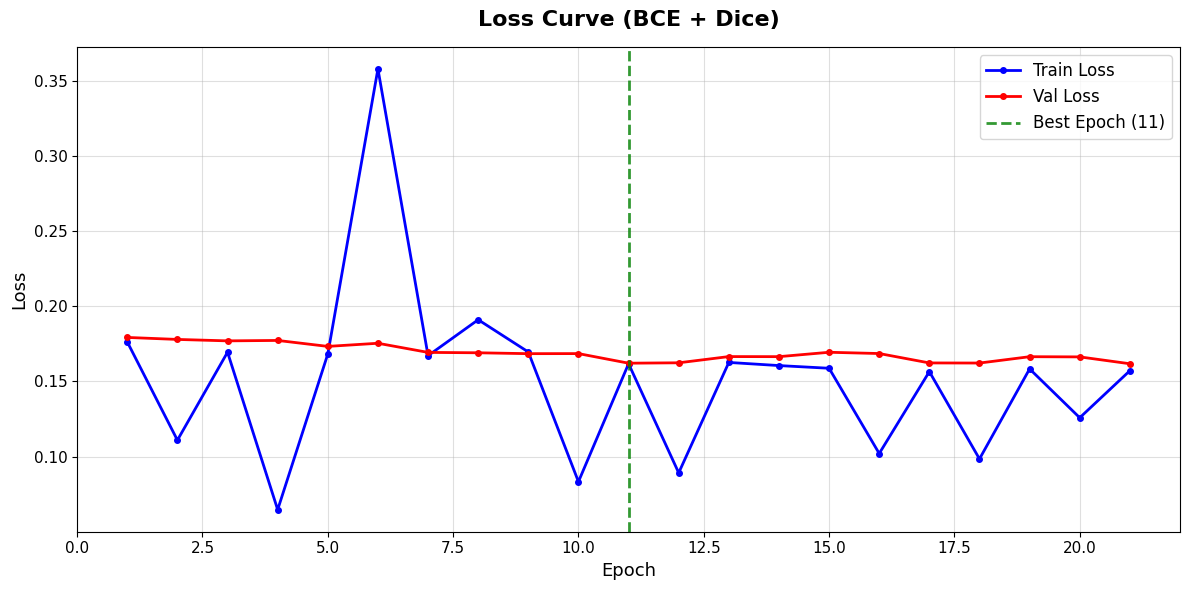

Loss curve saved → M4_loss_curve.png


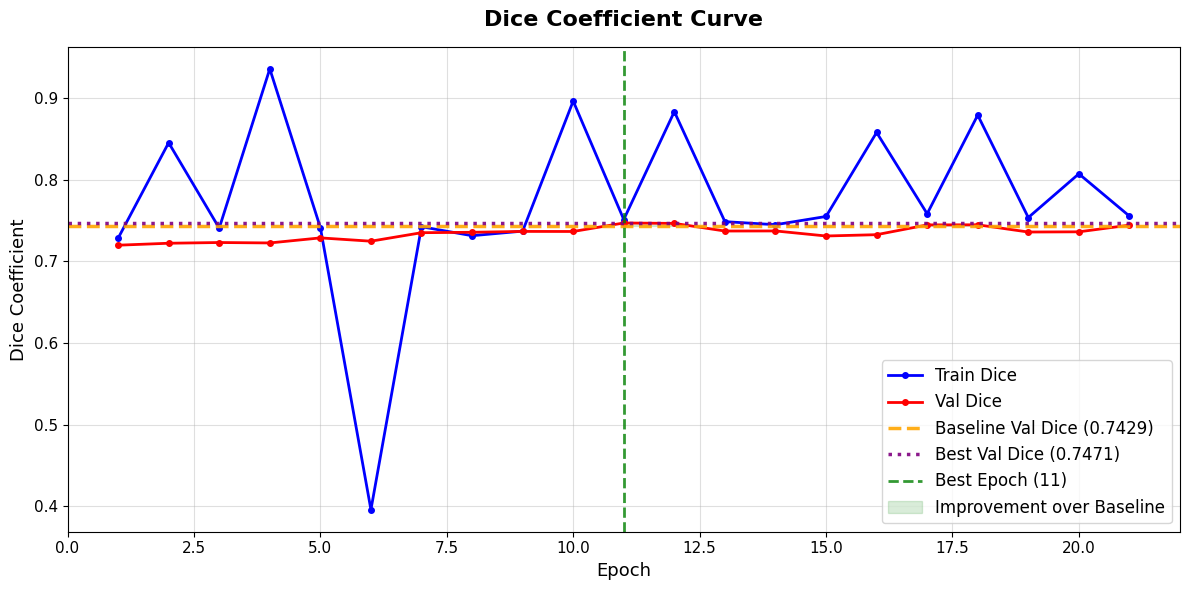

Dice curve saved → M4_dice_curve.png

Training Summary:
  Best Epoch        : 11
  Best Val Dice     : 0.7471
  Baseline Val Dice : 0.7429
  Improvement       : +0.0042


In [ ]:
# Cell 9: Plot Training Curves

def plot_training_history(history, baseline_dice=BASELINE['val_dice']):
    epochs_ran    = len(history.history['loss'])
    ep            = range(1, epochs_ran + 1)

    train_loss = history.history['loss']
    val_loss   = history.history['val_loss']
    train_dice = history.history['dice_coefficient']
    val_dice   = history.history['val_dice_coefficient']

    best_epoch    = np.argmax(val_dice) + 1
    best_val_dice = np.max(val_dice)

    # ── Figure 1: Loss ─────────────────────────────────────────────────
    fig1, ax1 = plt.subplots(figsize=(12, 6))
    ax1.plot(ep, train_loss, 'b-o', markersize=4, linewidth=2, label='Train Loss')
    ax1.plot(ep, val_loss,   'r-o', markersize=4, linewidth=2, label='Val Loss')
    ax1.axvline(x=best_epoch, color='green', linestyle='--',
                linewidth=2, alpha=0.8, label=f'Best Epoch ({best_epoch})')
    ax1.set_title('Loss Curve (BCE + Dice)', fontsize=16, fontweight='bold', pad=15)
    ax1.set_xlabel('Epoch', fontsize=13)
    ax1.set_ylabel('Loss',  fontsize=13)
    ax1.tick_params(labelsize=11)
    ax1.legend(fontsize=12)
    ax1.grid(True, alpha=0.4)
    fig1.tight_layout()
    fig1.savefig(BASE + 'M4_loss_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Loss curve saved → M4_loss_curve.png")

    # ── Figure 2: Dice ─────────────────────────────────────────────────
    fig2, ax2 = plt.subplots(figsize=(12, 6))
    ax2.plot(ep, train_dice, 'b-o', markersize=4, linewidth=2, label='Train Dice')
    ax2.plot(ep, val_dice,   'r-o', markersize=4, linewidth=2, label='Val Dice')
    ax2.axhline(y=baseline_dice,  color='orange', linestyle='--',
                linewidth=2.5, alpha=0.9, label=f'Baseline Val Dice ({baseline_dice:.4f})')
    ax2.axhline(y=best_val_dice,  color='purple', linestyle=':',
                linewidth=2.5, alpha=0.9, label=f'Best Val Dice ({best_val_dice:.4f})')
    ax2.axvline(x=best_epoch,     color='green',  linestyle='--',
                linewidth=2,   alpha=0.8, label=f'Best Epoch ({best_epoch})')

    # Shade improvement region between baseline and best val dice
    ax2.fill_between(ep, baseline_dice, val_dice,
                     where=[v > baseline_dice for v in val_dice],
                     alpha=0.15, color='green', label='Improvement over Baseline')

    ax2.set_title('Dice Coefficient Curve', fontsize=16, fontweight='bold', pad=15)
    ax2.set_xlabel('Epoch', fontsize=13)
    ax2.set_ylabel('Dice Coefficient', fontsize=13)
    ax2.tick_params(labelsize=11)
    ax2.legend(fontsize=12)
    ax2.grid(True, alpha=0.4)
    fig2.tight_layout()
    fig2.savefig(BASE + 'M4_dice_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Dice curve saved → M4_dice_curve.png")

    # ── Summary ────────────────────────────────────────────────────────
    print(f"\nTraining Summary:")
    print(f"  Best Epoch        : {best_epoch}")
    print(f"  Best Val Dice     : {best_val_dice:.4f}")
    print(f"  Baseline Val Dice : {baseline_dice:.4f}")
    print(f"  Improvement       : {best_val_dice - baseline_dice:+.4f}")

plot_training_history(history)

In [10]:
# Cell 10: Final Test Evaluation

print("Loading best fine-tuned model...")
best_model = tf.keras.models.load_model(
    FINETUNED_WEIGHTS,
    custom_objects=CUSTOM_OBJECTS
)
print(f"  ✓ Loaded from : {FINETUNED_WEIGHTS}")

# ── Run Predictions ────────────────────────────────────────────────────
print("\nRunning predictions on test set...")
t0          = time.time()
y_pred_prob = best_model.predict(X_test, batch_size=FT_BATCH_SIZE, verbose=1)
t1          = time.time()
print(f"  Inference time : {t1 - t0:.1f}s")
print(f"  y_pred shape   : {y_pred_prob.shape}")
print(f"  y_pred range   : [{y_pred_prob.min():.3f}, {y_pred_prob.max():.3f}]")

# ── Threshold at 0.5 ──────────────────────────────────────────────────
y_pred_bin = (y_pred_prob >= 0.5).astype(np.float32)

# ── Compute Metrics ────────────────────────────────────────────────────
print("\nComputing metrics...")
results = compute_metrics(y_test, y_pred_bin)

dice_scores  = [r['dice']        for r in results]
iou_scores   = [r['iou']         for r in results]
sens_scores  = [r['sensitivity'] for r in results]
prec_scores  = [r['precision']   for r in results]
spec_scores  = [r['specificity'] for r in results]

# ── Print Results ──────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("         Final Test Evaluation — M4 Fine-Tuned")
print("=" * 55)
print(f"  Test samples     : {len(X_test)}")
print(f"  Threshold        : 0.5")
print("-" * 55)
print(f"  Dice             : {np.mean(dice_scores):.4f} ± {np.std(dice_scores):.4f}")
print(f"  IoU              : {np.mean(iou_scores):.4f} ± {np.std(iou_scores):.4f}")
print(f"  Sensitivity      : {np.mean(sens_scores):.4f} ± {np.std(sens_scores):.4f}")
print(f"  Precision        : {np.mean(prec_scores):.4f} ± {np.std(prec_scores):.4f}")
print(f"  Specificity      : {np.mean(spec_scores):.4f} ± {np.std(spec_scores):.4f}")
print("-" * 55)
print(f"  Baseline Dice    : {BASELINE['test_dice']:.4f} ± {BASELINE['test_dice_std']:.4f}")
print(f"  Improvement      : {np.mean(dice_scores) - BASELINE['test_dice']:+.4f}")
print("=" * 55)

# ── Store for comparison table in Cell 11 ─────────────────────────────
FT_RESULTS = {
    'test_dice'     : np.mean(dice_scores),
    'test_dice_std' : np.std(dice_scores),
    'test_iou'      : np.mean(iou_scores),
    'sensitivity'   : np.mean(sens_scores),
    'precision'     : np.mean(prec_scores),
    'specificity'   : np.mean(spec_scores)
}
print("\nFT_RESULTS stored for Cell 11 comparison table ✓")

Loading best fine-tuned model...
  ✓ Loaded from : /content/drive/MyDrive/LungTumour/M4_finetuned_best.keras

Running predictions on test set...
198/198 ━━━━━━━━━━━━━━━━━━━━ 18s 66ms/step
  Inference time : 18.9s
  y_pred shape   : (395, 8, 128, 128, 1)
  y_pred range   : [0.000, 1.000]

Computing metrics...

         Final Test Evaluation — M4 Fine-Tuned
  Test samples     : 395
  Threshold        : 0.5
-------------------------------------------------------
  Dice             : 0.7380 ± 0.2051
  IoU              : 0.6172 ± 0.2032
  Sensitivity      : 0.7957 ± 0.2169
  Precision        : 0.7528 ± 0.2175
  Specificity      : 0.9990 ± 0.0021
-------------------------------------------------------
  Baseline Dice    : 0.7234 ± 0.2219
  Improvement      : +0.0146

FT_RESULTS stored for Cell 11 comparison table ✓


        Baseline  vs  Fine-Tuned (M4) — Test Set Comparison
  Metric           Baseline   Fine-Tuned     Change
--------------------------------------------------------------
  Dice               0.7234       0.7380 ▲  0.0146
  IoU                0.6031       0.6172 ▲  0.0141
  Sensitivity        0.7168       0.7957 ▲  0.0789
  Precision          0.8229       0.7528 ▼  0.0701
  Specificity        0.9994       0.9990 ▼  0.0004
--------------------------------------------------------------
  Dice Std           0.2219       0.2051


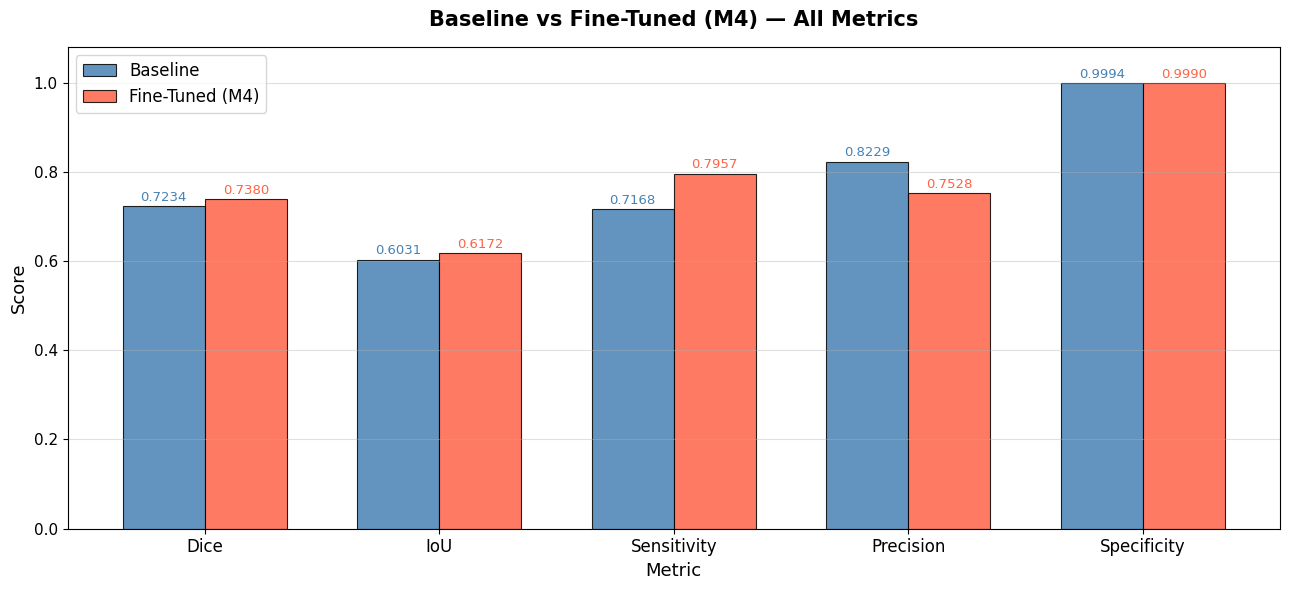

Comparison chart saved → M4_comparison_chart.png


In [11]:
# Cell 11: Baseline vs Fine-Tuned Comparison Table

# ── Console Table ──────────────────────────────────────────────────────
metrics_to_compare = ['test_dice', 'test_iou', 'sensitivity', 'precision', 'specificity']
metric_labels      = ['Dice',      'IoU',      'Sensitivity', 'Precision', 'Specificity']

print("=" * 62)
print("        Baseline  vs  Fine-Tuned (M4) — Test Set Comparison")
print("=" * 62)
print(f"  {'Metric':<14} {'Baseline':>10} {'Fine-Tuned':>12} {'Change':>10}")
print("-" * 62)

for key, label in zip(metrics_to_compare, metric_labels):
    base_val = BASELINE.get(key, None)
    ft_val   = FT_RESULTS.get(key, None)

    if base_val is not None and ft_val is not None:
        delta  = ft_val - base_val
        arrow  = '▲' if delta > 0 else '▼'
        print(f"  {label:<14} {base_val:>10.4f} {ft_val:>12.4f} {arrow}{abs(delta):>8.4f}")

print("-" * 62)
print(f"  {'Dice Std':<14} {BASELINE['test_dice_std']:>10.4f} "
      f"{FT_RESULTS['test_dice_std']:>12.4f}")
print("=" * 62)

# ── Bar Chart ──────────────────────────────────────────────────────────
baseline_vals = [BASELINE.get(k, 0)   for k in metrics_to_compare]
ft_vals       = [FT_RESULTS.get(k, 0) for k in metrics_to_compare]

x      = np.arange(len(metric_labels))
width  = 0.35

fig, ax = plt.subplots(figsize=(13, 6))

bars1 = ax.bar(x - width/2, baseline_vals, width,
               label='Baseline', color='steelblue',  alpha=0.85, edgecolor='black', linewidth=0.8)
bars2 = ax.bar(x + width/2, ft_vals,       width,
               label='Fine-Tuned (M4)', color='tomato', alpha=0.85, edgecolor='black', linewidth=0.8)

# Value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9.5, color='steelblue')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9.5, color='tomato')

ax.set_title('Baseline vs Fine-Tuned (M4) — All Metrics',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Metric',      fontsize=13)
ax.set_ylabel('Score',       fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=12)
ax.tick_params(axis='y', labelsize=11)
ax.set_ylim(0, 1.08)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.4)

fig.tight_layout()
fig.savefig(BASE + 'M4_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comparison chart saved → M4_comparison_chart.png")